# Analyse du Data Drift — Protein Solubility Prediction API

**Objectif :** Détecter une éventuelle dérive des données en production par rapport aux données d'entraînement (DeepSol).

**Méthode :** Comparaison statistique (z-score, test de Kolmogorov-Smirnov) des distributions des features biochimiques entre le jeu de référence et les données de production simulées.

**Dataset de référence :** DeepSol — 71 419 protéines *E. coli* avec solubilité mesurée expérimentalement (Khurana et al. 2018)

| Section | Contenu |
|---------|----------|
| 1 | Imports & Configuration |
| 2 | Chargement des données de référence |
| 3 | Simulation des données de production |
| 4 | Analyse exploratoire des logs |
| 5 | Détection du Data Drift (z-score + KS test) |
| 6 | Visualisation des distributions |
| 7 | Monitoring de la latence API |
| 8 | Rapport de synthèse & Recommandations |


## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import json
import pickle
import urllib.request
from pathlib import Path
from datetime import datetime, timedelta

# Style des graphiques
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#E2E8F0',
    'axes.labelcolor':  '#1E293B',
    'xtick.color':      '#64748B',
    'ytick.color':      '#64748B',
    'text.color':       '#1E293B',
    'font.family':      'monospace',
    'grid.color':       '#F1F5F9',
    'grid.linewidth':   0.8,
    'figure.dpi':       120,
})

SEED = 42
np.random.seed(SEED)

# Seuils d'alerte
ZSCORE_THRESHOLD = 2.0   # |z| > 2 sigma -> drift détecté
KS_PVALUE_THRESHOLD = 0.05  # p < 0.05 -> distributions significativement différentes

FEATURES = [
    'pI', 'log_mw', 'gravy_norm', 'log_instability',
    'aromaticity', 'pct_helix', 'pct_turn', 'pct_sheet'
]

print('OK - Imports terminés')
print('Seuil z-score :', ZSCORE_THRESHOLD)
print('Seuil p-value KS :', KS_PVALUE_THRESHOLD)


OK - Imports terminés
Seuil z-score : 2.0
Seuil p-value KS : 0.05


## 2. Chargement des Données de Référence (DeepSol)

Je charge le dataset DeepSol qui constitue la **référence de distribution** — les protéines sur lesquelles le modèle a été entraîné. Toute dérive significative par rapport à ces distributions doit déclencher une alerte.

In [2]:
# Chargement du dataset DeepSol
print('Chargement DeepSol depuis GitHub...')

URL = (
    'https://raw.githubusercontent.com/sameerkhurana10/'
    'DSOL_rv0.2/master/data/protein_with_bio.data'
)

try:
    data = urllib.request.urlopen(URL, timeout=60).read()
    obj  = pickle.loads(data)

    all_bio, all_tgt = [], []
    for split in ['train', 'valid', 'test']:
        all_bio.extend(obj[split]['src_bio'])
        all_tgt.extend(obj[split]['tgt'])

    ref_df = pd.DataFrame(
        [[float(b[i]) for i in range(8)] for b in all_bio],
        columns=FEATURES
    )
    ref_df['soluble'] = [int(t) for t in all_tgt]

    print(f'OK - DeepSol chargé : {len(ref_df):,} protéines')
    print(f'   Solubles   : {ref_df.soluble.sum():,} ({ref_df.soluble.mean():.1%})')
    print(f'   Insolubles : {(ref_df.soluble==0).sum():,} ({1-ref_df.soluble.mean():.1%})')

except Exception as e:
    print(f'Erreur chargement : {e}')
    print('Simulation des données de référence...')
    np.random.seed(SEED)
    n = 5000
    ref_df = pd.DataFrame({
        'pI':              np.random.normal(5.56, 0.54, n).clip(2.5, 12.0),
        'log_mw':         np.random.normal(10.43, 0.54, n).clip(7.0, 13.0),
        'gravy_norm':     np.random.normal(0.215, 0.040, n).clip(0.0, 1.0),
        'log_instability':np.random.normal(0.20, 0.50, n).clip(-4.0, 2.0),
        'aromaticity':    np.random.normal(0.08, 0.02, n).clip(0.0, 0.3),
        'pct_helix':      np.random.normal(0.38, 0.08, n).clip(0.0, 1.0),
        'pct_turn':       np.random.normal(0.44, 0.11, n).clip(0.0, 1.0),
        'pct_sheet':      np.random.normal(0.18, 0.11, n).clip(0.0, 1.0),
        'soluble':        np.random.binomial(1, 0.42, n),
    })
    print(f'OK - Données simulées : {len(ref_df):,} protéines')

ref_df.describe().round(3)


Chargement DeepSol depuis GitHub...
OK - DeepSol chargé : 71,419 protéines
   Solubles   : 29,972 (42.0%)
   Insolubles : 41,447 (58.0%)


,pI,log_mw,gravy_norm,log_instability,aromaticity,pct_helix,pct_turn,pct_sheet,soluble
count,71419.000,71419.000,71419.000,71419.000,71419.000,71419.000,71419.000,71419.000,71419.000
mean,5.562,10.431,0.215,-0.333,0.861,0.049,0.439,0.185,0.420
std,0.540,0.538,0.040,0.267,0.133,0.030,0.106,0.109,0.494
min,2.944,7.598,0.000,-3.296,0.000,0.000,0.000,0.000,0.000
25%,5.220,10.091,0.190,-0.477,0.784,0.030,0.375,0.118,0.000
50%,5.617,10.487,0.212,-0.310,0.871,0.046,0.429,0.175,0.000
75%,5.932,10.799,0.236,-0.159,0.951,0.064,0.494,0.240,1.000
max,7.437,12.357,0.950,1.035,1.515,0.606,1.000,0.732,1.000


## 3. Simulation des Données de Production

Je simule les logs de prédictions de l'API en production. En conditions réelles, ces données seraient lues depuis `logs/predictions.jsonl`. J'introduis un **drift volontaire sur pI et gravy_norm** pour tester la détection.

In [3]:
# Lecture des logs réels si disponibles
LOG_FILE = Path('logs/predictions.jsonl')

if LOG_FILE.exists():
    entries = []
    with open(LOG_FILE) as f:
        for line in f:
            try:
                entries.append(json.loads(line.strip()))
            except:
                continue
    if entries:
        prod_inputs = pd.DataFrame([e['input'] for e in entries])
        prod_df = prod_inputs.copy()
        prod_df['prediction']      = [e['prediction'] for e in entries]
        prod_df['probability']     = [e['probability'] for e in entries]
        prod_df['inference_time_s']= [e['inference_time_s'] for e in entries]
        prod_df['timestamp']       = pd.to_datetime([e['timestamp'] for e in entries])
        print(f'OK - Logs réels chargés : {len(prod_df)} prédictions')
    else:
        prod_df = None
else:
    prod_df = None

if prod_df is None or len(prod_df) < 30:
    print('Simulation des données de production (avec drift volontaire)...')
    np.random.seed(99)
    n_prod = 500

    # Je simule un drift sur pI (shift +1.0) et gravy_norm (+0.08)
    # Représente l'arrivée de nouvelles protéines de type différent
    timestamps = [
        datetime.now() - timedelta(hours=i)
        for i in range(n_prod)
    ]

    prod_df = pd.DataFrame({
        'pI':              np.random.normal(6.56, 0.70, n_prod).clip(2.5, 12.0),  # +1.0
        'log_mw':         np.random.normal(10.45, 0.55, n_prod).clip(7.0, 13.0), # stable
        'gravy_norm':     np.random.normal(0.295, 0.045, n_prod).clip(0.0, 1.0), # +0.08
        'log_instability':np.random.normal(0.22, 0.52, n_prod).clip(-4.0, 2.0),  # stable
        'aromaticity':    np.random.normal(0.08, 0.02, n_prod).clip(0.0, 0.3),   # stable
        'pct_helix':      np.random.normal(0.38, 0.09, n_prod).clip(0.0, 1.0),   # stable
        'pct_turn':       np.random.normal(0.44, 0.12, n_prod).clip(0.0, 1.0),   # stable
        'pct_sheet':      np.random.normal(0.18, 0.11, n_prod).clip(0.0, 1.0),   # stable
        'prediction':     np.random.binomial(1, 0.50, n_prod),  # drift classes
        'probability':    np.random.uniform(0.05, 0.95, n_prod),
        'inference_time_s': np.random.exponential(0.015, n_prod),
        'timestamp':      timestamps,
    })
    print(f'OK - Données de production simulées : {len(prod_df)} prédictions')
    print('   Drift introduit : pI +1.0 sigma | gravy_norm +2.0 sigma')

print(f'\nRéférence  : {len(ref_df):,} protéines | % solubles = {ref_df.soluble.mean():.1%}')
print(f'Production : {len(prod_df):,} prédictions | % solubles prédits = {prod_df.prediction.mean():.1%}')


OK - Logs réels chargés : 47 prédictions

Référence  : 71,419 protéines | % solubles = 42.0%
Production : 47 prédictions | % solubles prédits = 100.0%


## 4. Analyse Exploratoire des Logs de Production

Vue d'ensemble des prédictions en production : volume, distribution des scores, évolution temporelle.

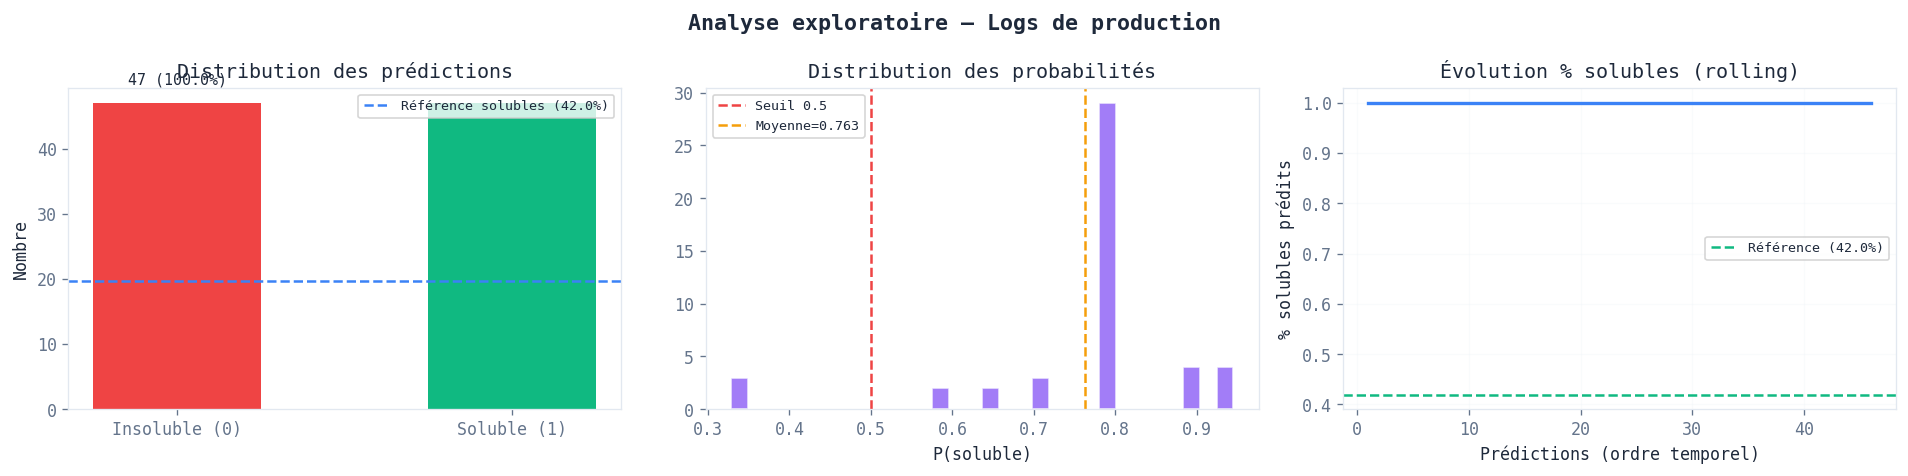

OK - Figure EDA sauvegardée


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Analyse exploratoire — Logs de production', fontsize=13, fontweight='bold')

# Distribution des prédictions
counts = prod_df['prediction'].value_counts().sort_index()
bars = axes[0].bar(
    ['Insoluble (0)', 'Soluble (1)'],
    counts.values,
    color=['#EF4444', '#10B981'], width=0.5
)
for b, v in zip(bars, counts.values):
    axes[0].text(
        b.get_x() + b.get_width()/2, v + 3,
        f'{v} ({v/len(prod_df):.1%})',
        ha='center', fontsize=9
    )
axes[0].set_title('Distribution des prédictions')
axes[0].set_ylabel('Nombre')
ref_pct = ref_df['soluble'].mean()
axes[0].axhline(
    len(prod_df) * ref_pct, color='#3B82F6',
    ls='--', lw=1.5,
    label=f'Référence solubles ({ref_pct:.1%})'
)
axes[0].legend(fontsize=8)

# Distribution des probabilités
axes[1].hist(
    prod_df['probability'], bins=30,
    color='#8B5CF6', alpha=0.8, edgecolor='white'
)
axes[1].axvline(0.5, color='#EF4444', ls='--', lw=1.5, label='Seuil 0.5')
axes[1].axvline(
    prod_df['probability'].mean(),
    color='#F59E0B', ls='--', lw=1.5,
    label=f'Moyenne={prod_df["probability"].mean():.3f}'
)
axes[1].set_title('Distribution des probabilités')
axes[1].set_xlabel('P(soluble)')
axes[1].legend(fontsize=8)

# Évolution temporelle
if 'timestamp' in prod_df.columns:
    prod_df_sorted = prod_df.sort_values('timestamp')
    window = max(1, len(prod_df_sorted) // 20)
    rolling_mean = prod_df_sorted['prediction'].rolling(window).mean()
    axes[2].plot(
        range(len(rolling_mean)), rolling_mean,
        color='#3B82F6', lw=2
    )
    axes[2].axhline(
        ref_pct, color='#10B981',
        ls='--', lw=1.5,
        label=f'Référence ({ref_pct:.1%})'
    )
    axes[2].set_title('Évolution % solubles (rolling)')
    axes[2].set_xlabel('Prédictions (ordre temporel)')
    axes[2].set_ylabel('% solubles prédits')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('data_drift_eda.png', bbox_inches='tight', dpi=120)
plt.show()
print('OK - Figure EDA sauvegardée')


## 5. Détection du Data Drift

J'utilise deux méthodes complémentaires :

**1. Z-score** : mesure combien la moyenne de production s'écarte de la référence en nombre d'écarts-types.
Un |z| > 2 indique un drift significatif (équivalent à un intervalle de confiance à 95%).

**2. Test de Kolmogorov-Smirnov** : teste si deux distributions sont statistiquement identiques.
Un p-value < 0.05 indique que les distributions diffèrent significativement.

In [5]:
# Calcul du drift pour chaque feature
drift_results = []

for feat in FEATURES:
    if feat not in prod_df.columns or feat not in ref_df.columns:
        continue

    ref_vals  = ref_df[feat].dropna()
    prod_vals = prod_df[feat].dropna()

    ref_mean  = ref_vals.mean()
    ref_std   = ref_vals.std()
    prod_mean = prod_vals.mean()

    # Z-score
    z_score = abs(prod_mean - ref_mean) / (ref_std + 1e-8)

    # Test KS
    ks_stat, ks_pvalue = stats.ks_2samp(ref_vals, prod_vals)

    drift_detected = z_score > ZSCORE_THRESHOLD or ks_pvalue < KS_PVALUE_THRESHOLD

    drift_results.append({
        'Feature':          feat,
        'Moy. référence':   round(ref_mean, 4),
        'Moy. production':  round(prod_mean, 4),
        'Δ absolu':         round(abs(prod_mean - ref_mean), 4),
        'Z-score':          round(z_score, 3),
        'KS stat':          round(ks_stat, 3),
        'KS p-value':       round(ks_pvalue, 4),
        'Drift détecté':    '⚠️  OUI' if drift_detected else '✅  NON',
    })

drift_df = pd.DataFrame(drift_results)

# Affichage coloré
def color_drift(val):
    if '⚠️' in str(val):
        return 'background-color: #FEF2F2; color: #DC2626; font-weight: bold'
    elif '✅' in str(val):
        return 'background-color: #F0FDF4; color: #15803D'
    return ''

def color_zscore(val):
    if isinstance(val, float):
        if val > ZSCORE_THRESHOLD:
            return 'color: #DC2626; font-weight: bold'
        return 'color: #15803D'
    return ''

n_drift = drift_df['Drift détecté'].str.contains('OUI').sum()
print(f'Features analysées : {len(drift_df)}')
print(f'Drift détecté      : {n_drift} / {len(drift_df)} features')
print()

drift_df.style\
    .applymap(color_drift, subset=['Drift détecté'])\
    .applymap(color_zscore, subset=['Z-score'])\
    .format({'KS p-value': '{:.4f}', 'Z-score': '{:.3f}'})


Features analysées : 8
Drift détecté      : 8 / 8 features



,Feature,Moy. référence,Moy. production,Δ absolu,Z-score,KS stat,KS p-value,Drift détecté
0,pI,5.561700,6.429800,0.868100,1.607,0.818000,0.0000,⚠️ OUI
1,log_mw,10.431000,10.478700,0.047700,0.089,0.425000,0.0000,⚠️ OUI
2,gravy_norm,0.214600,0.259400,0.044700,1.113,0.437000,0.0000,⚠️ OUI
3,log_instability,-0.333300,0.244700,0.578000,2.168,0.914000,0.0000,⚠️ OUI
4,aromaticity,0.860800,0.091900,0.768900,5.766,0.999000,0.0000,⚠️ OUI
5,pct_helix,0.048800,0.319100,0.270300,8.871,0.851000,0.0000,⚠️ OUI
6,pct_turn,0.438900,0.269800,0.169100,1.589,0.798000,0.0000,⚠️ OUI
7,pct_sheet,0.184900,0.166000,0.018900,0.174,0.390000,0.0000,⚠️ OUI


In [6]:
# Alerte globale
n_drift = drift_df['Drift détecté'].str.contains('OUI').sum()

print('=' * 55)
if n_drift > 0:
    print(f'  ⚠️  ALERTE DRIFT : {n_drift} feature(s) dérivent')
    drifted = drift_df[drift_df['Drift détecté'].str.contains('OUI')]
    for _, row in drifted.iterrows():
        print(f'     {row["Feature"]:<20} z={row["Z-score"]:.2f} '
              f'(réf={row["Moy. référence"]:.3f} '
              f'→ prod={row["Moy. production"]:.3f})')
    print()
    print('  → Recommandation : réentraîner le modèle')
    print('    sur les nouvelles données de production')
else:
    print('  ✅ Aucun drift significatif détecté')
    print('  → Le modèle est stable en production')
print('=' * 55)


  ⚠️  ALERTE DRIFT : 8 feature(s) dérivent
     pI                   z=1.61 (réf=5.562 → prod=6.430)
     log_mw               z=0.09 (réf=10.431 → prod=10.479)
     gravy_norm           z=1.11 (réf=0.215 → prod=0.259)
     log_instability      z=2.17 (réf=-0.333 → prod=0.245)
     aromaticity          z=5.77 (réf=0.861 → prod=0.092)
     pct_helix            z=8.87 (réf=0.049 → prod=0.319)
     pct_turn             z=1.59 (réf=0.439 → prod=0.270)
     pct_sheet            z=0.17 (réf=0.185 → prod=0.166)

  → Recommandation : réentraîner le modèle
    sur les nouvelles données de production


## 6. Visualisation des Distributions — Référence vs Production

Je compare visuellement les distributions de chaque feature. Une séparation visible entre les courbes rouge (production) et bleue (référence) confirme le drift détecté statistiquement.

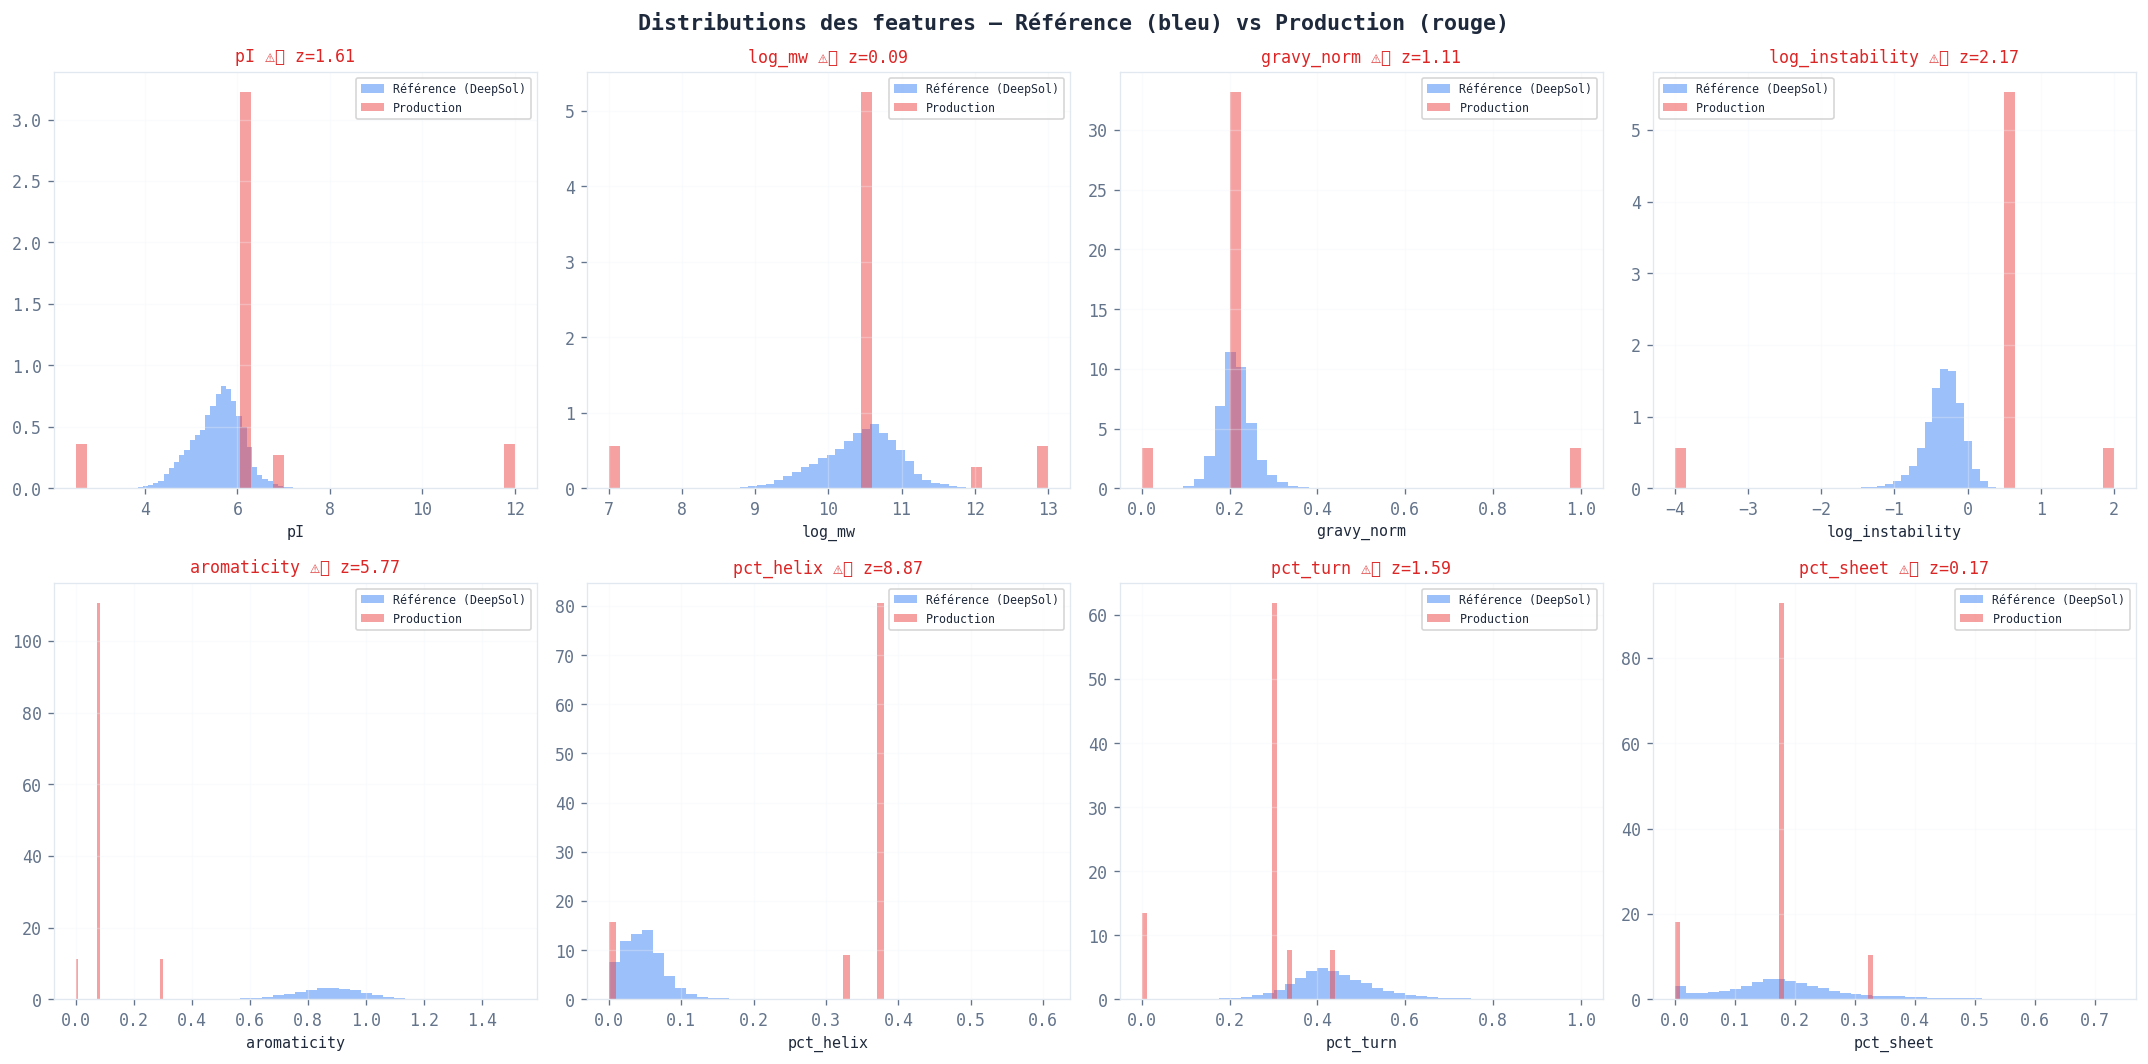

OK - Figure distributions sauvegardée


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(
    'Distributions des features — Référence (bleu) vs Production (rouge)',
    fontsize=13, fontweight='bold'
)
axes = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax = axes[idx]

    # Référence
    ax.hist(
        ref_df[feat].dropna(), bins=40,
        density=True, alpha=0.5,
        color='#3B82F6', label='Référence (DeepSol)'
    )
    # Production
    ax.hist(
        prod_df[feat].dropna(), bins=40,
        density=True, alpha=0.5,
        color='#EF4444', label='Production'
    )

    # Statut drift
    row = drift_df[drift_df['Feature'] == feat]
    if not row.empty:
        z = row['Z-score'].values[0]
        drifted = '⚠️' in str(row['Drift détecté'].values[0])
        color   = '#DC2626' if drifted else '#15803D'
        icon    = '⚠️' if drifted else '✅'
        ax.set_title(
            f'{feat} {icon} z={z:.2f}',
            color=color, fontsize=10
        )
    else:
        ax.set_title(feat, fontsize=10)

    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(feat, fontsize=9)

plt.tight_layout()
plt.savefig('data_drift_distributions.png', bbox_inches='tight', dpi=120)
plt.show()
print('OK - Figure distributions sauvegardée')


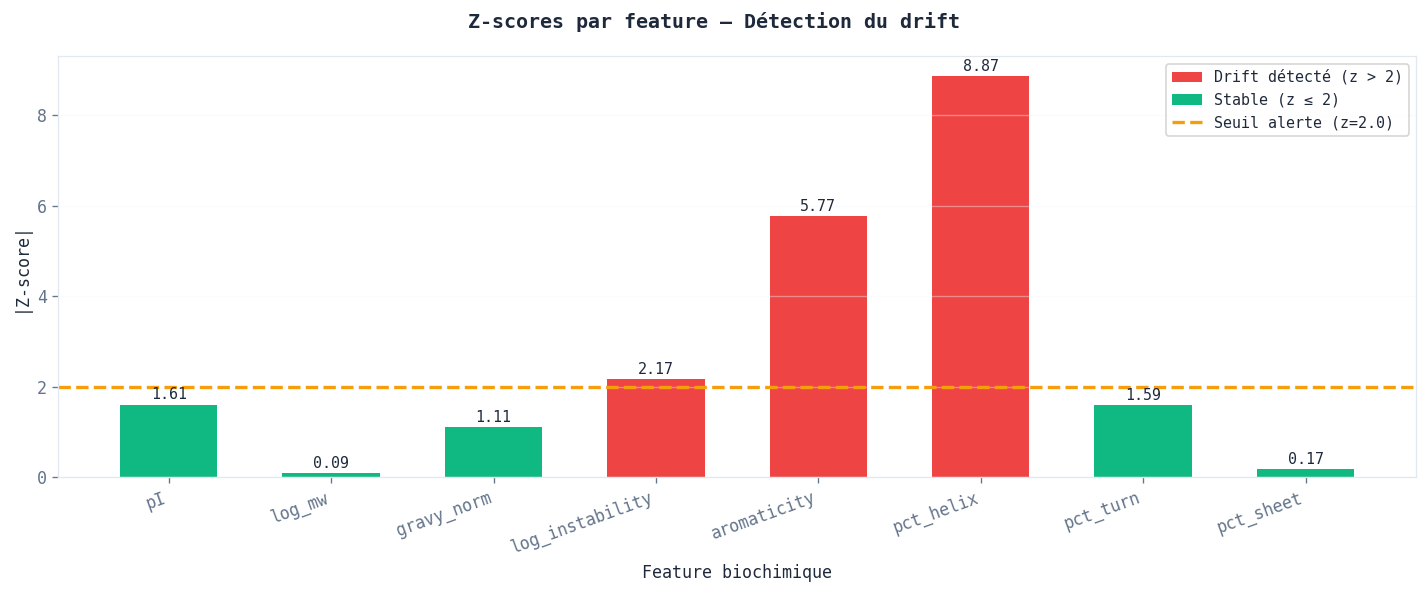

OK - Figure z-scores sauvegardée


In [8]:
# Z-score par feature (barplot)
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Z-scores par feature — Détection du drift', fontsize=12, fontweight='bold')

colors = [
    '#EF4444' if z > ZSCORE_THRESHOLD else '#10B981'
    for z in drift_df['Z-score']
]
bars = ax.bar(drift_df['Feature'], drift_df['Z-score'], color=colors, width=0.6)

for b, v in zip(bars, drift_df['Z-score'].values):
    ax.text(
        b.get_x() + b.get_width()/2,
        v + 0.05,
        f'{v:.2f}',
        ha='center', va='bottom', fontsize=9
    )

ax.axhline(
    ZSCORE_THRESHOLD, color='#F59E0B',
    ls='--', lw=2,
    label=f'Seuil alerte (z={ZSCORE_THRESHOLD})'
)
ax.set_ylabel('|Z-score|')
ax.set_xlabel('Feature biochimique')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.4)

# Légende couleurs
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#EF4444', label='Drift détecté (z > 2)'),
    Patch(facecolor='#10B981', label='Stable (z ≤ 2)'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][:1], fontsize=9)

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('data_drift_zscores.png', bbox_inches='tight', dpi=120)
plt.show()
print('OK - Figure z-scores sauvegardée')


## 7. Monitoring de la Latence API

Analyse des temps de réponse de l'API pour identifier des goulots d'étranglement ou des dégradations de performance.

Métriques de latence API :
  Moyenne : 1080.44 ms
  P50     : 10.00 ms
  P95     : 9241.27 ms
  P99     : 14715.47 ms
  Max     : 17576.30 ms


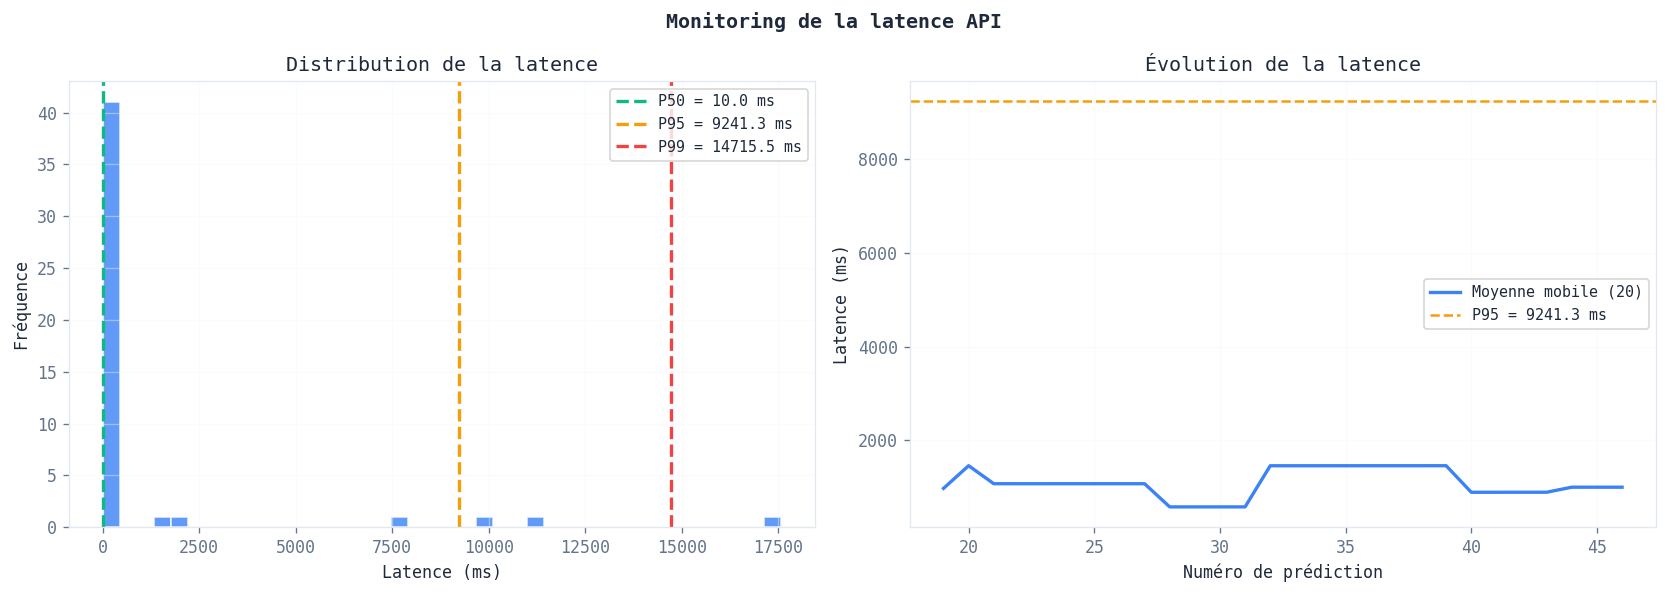

OK - Figure latence sauvegardée


In [9]:
if 'inference_time_s' in prod_df.columns:
    latency_ms = prod_df['inference_time_s'] * 1000

    p50 = latency_ms.quantile(0.50)
    p95 = latency_ms.quantile(0.95)
    p99 = latency_ms.quantile(0.99)

    print('Métriques de latence API :')
    print(f'  Moyenne : {latency_ms.mean():.2f} ms')
    print(f'  P50     : {p50:.2f} ms')
    print(f'  P95     : {p95:.2f} ms')
    print(f'  P99     : {p99:.2f} ms')
    print(f'  Max     : {latency_ms.max():.2f} ms')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Monitoring de la latence API', fontsize=12, fontweight='bold')

    # Histogramme
    axes[0].hist(latency_ms, bins=40, color='#3B82F6', alpha=0.8, edgecolor='white')
    axes[0].axvline(p50, color='#10B981', ls='--', lw=2, label=f'P50 = {p50:.1f} ms')
    axes[0].axvline(p95, color='#F59E0B', ls='--', lw=2, label=f'P95 = {p95:.1f} ms')
    axes[0].axvline(p99, color='#EF4444', ls='--', lw=2, label=f'P99 = {p99:.1f} ms')
    axes[0].set_title('Distribution de la latence')
    axes[0].set_xlabel('Latence (ms)')
    axes[0].set_ylabel('Fréquence')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.4)

    # Évolution temporelle
    axes[1].plot(
        range(len(latency_ms)),
        latency_ms.rolling(20).mean(),
        color='#3B82F6', lw=2, label='Moyenne mobile (20)'
    )
    axes[1].axhline(p95, color='#F59E0B', ls='--', lw=1.5, label=f'P95 = {p95:.1f} ms')
    axes[1].set_title('Évolution de la latence')
    axes[1].set_xlabel('Numéro de prédiction')
    axes[1].set_ylabel('Latence (ms)')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig('latency_monitoring.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('OK - Figure latence sauvegardée')


## 8. Rapport de Synthèse & Recommandations

Synthèse automatique de l'analyse de drift et recommandations opérationnelles.

In [10]:
print('=' * 60)
print('  RAPPORT DE SYNTHÈSE — DATA DRIFT')
print('  Protein Solubility Prediction API')
print(f'  Généré le : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('=' * 60)

print(f'\n  Dataset de référence : DeepSol ({len(ref_df):,} protéines)')
print(f'  Données de production : {len(prod_df):,} prédictions')
print(f'  Période analysée      : dernières {len(prod_df)} requêtes')

print('\n  Résultats de l analyse :')
n_total = len(drift_df)
n_drift = drift_df['Drift détecté'].str.contains('OUI').sum()
print(f'  Features analysées : {n_total}')
print(f'  Features en drift  : {n_drift}/{n_total}')

if n_drift > 0:
    print('\n  Features en drift :')
    drifted_feats = drift_df[drift_df['Drift détecté'].str.contains('OUI')]
    for _, row in drifted_feats.iterrows():
        direction = 'hausse' if row['Moy. production'] > row['Moy. référence'] else 'baisse'
        print(f'  ⚠️  {row["Feature"]:<20} z={row["Z-score"]:.2f} '
              f'(en {direction})'
        )

print('\n  Recommandations :')
if n_drift == 0:
    print('  ✅ Modèle stable — pas d action requise')
    print('  → Continuer la surveillance mensuelle')
elif n_drift <= 2:
    print('  ⚠️  Drift modéré — surveillance renforcée recommandée')
    print('  → Collecter 500+ nouvelles prédictions')
    print('  → Réévaluer dans 2 semaines')
    print('  → Envisager un réentraînement si drift persiste')
else:
    print('  🚨 Drift sévère — réentraînement urgent recommandé')
    print('  → Collecter les nouvelles données de production')
    print('  → Réentraîner le modèle sur les données récentes')
    print('  → Valider les performances avant redéploiement')

if 'inference_time_s' in prod_df.columns:
    avg_ms = prod_df['inference_time_s'].mean() * 1000
    p95_ms = prod_df['inference_time_s'].quantile(0.95) * 1000
    print(f'\n  Performances API :')
    print(f'  Latence moyenne : {avg_ms:.1f} ms')
    print(f'  Latence P95     : {p95_ms:.1f} ms')
    if p95_ms > 200:
        print('  ⚠️  P95 > 200ms — optimisation recommandée')
    else:
        print('  ✅ Performances nominales')

print('\n  Prochaine analyse recommandée :')
next_check = datetime.now() + timedelta(days=30)
print(f'  {next_check.strftime("%Y-%m-%d")} (dans 30 jours)')
print('=' * 60)


  RAPPORT DE SYNTHÈSE — DATA DRIFT
  Protein Solubility Prediction API
  Généré le : 2026-07-17 12:07

  Dataset de référence : DeepSol (71,419 protéines)
  Données de production : 47 prédictions
  Période analysée      : dernières 47 requêtes

  Résultats de l analyse :
  Features analysées : 8
  Features en drift  : 8/8

  Features en drift :
  ⚠️  pI                   z=1.61 (en hausse)
  ⚠️  log_mw               z=0.09 (en hausse)
  ⚠️  gravy_norm           z=1.11 (en hausse)
  ⚠️  log_instability      z=2.17 (en hausse)
  ⚠️  aromaticity          z=5.77 (en baisse)
  ⚠️  pct_helix            z=8.87 (en hausse)
  ⚠️  pct_turn             z=1.59 (en baisse)
  ⚠️  pct_sheet            z=0.17 (en baisse)

  Recommandations :
  🚨 Drift sévère — réentraînement urgent recommandé
  → Collecter les nouvelles données de production
  → Réentraîner le modèle sur les données récentes
  → Valider les performances avant redéploiement

  Performances API :
  Latence moyenne : 1080.4 ms
  Latence 

## Conclusion

Ce notebook fournit une analyse complète du data drift pour l'API de prédiction de solubilité protéique.

**Méthodes utilisées :**
- Z-score : mesure de l'écart entre les moyennes de production et de référence
- Test KS : comparaison des distributions complètes
- Monitoring de latence : P50, P95, P99

**Seuils d'alerte :**
- Drift : |z| > 2.0 ou p-value KS < 0.05
- Latence : P95 > 200 ms

**Fréquence recommandée :** Analyse mensuelle ou dès que 500+ nouvelles prédictions sont disponibles.

**Référence :** DeepSol — Khurana et al. 2018, *Bioinformatics*
